In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
model = ChatOpenAI()

In [3]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {
        "messages": [response]
    }

In [4]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

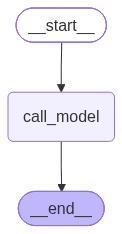

In [5]:
graph = builder.compile()
graph

In [6]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Aneesh."}]})

{'messages': [HumanMessage(content='Hi! My name is Aneesh.', additional_kwargs={}, response_metadata={}, id='26e3ae56-1ec3-4907-96fd-6e4ca22b1270'),
  AIMessage(content='Hello Aneesh! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 16, 'total_tokens': 28, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E9y9xVC2Kx4GHhbH2qbGK9t9Io7rs', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fd892-95a1-7223-9dd3-71f6d0892830-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 12, 'total_tokens': 28, 'input_token_details': {'audio': 0,

In [7]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='dc07944e-e11a-4cff-b4c5-5cf5627ddbb6'),
  AIMessage(content="I'm sorry, I am an AI digital assistant and do not have the capability to know personal information about users unless it has been shared with me in the course of our conversation.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 12, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E9yA0EOpcBiwWIie1RkMRY0A0VIH3', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fd892-9b1c-74a0-8839-7f50346083fb-0', tool_calls=[], in

Now same graph with Memory

In [8]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {
        "messages": [response]
    }

In [9]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [10]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [13]:
config = {"configurable": {"thread_id": "thread-1"}}

In [14]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Aneesh."}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Aneesh.', additional_kwargs={}, response_metadata={}, id='57948962-37c4-4efe-83e6-15ecbddaae03'),
  AIMessage(content="Hello, Aneesh! It's nice to meet you. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 16, 'total_tokens': 36, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E9yAz66nQKr9BKfZ5h0KgzIVePn4P', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fd893-89df-7593-ad1f-009b364c6593-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 20, 'total_tokens': 36, 'input_toke

In [15]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)


{'messages': [HumanMessage(content='Hi! My name is Aneesh.', additional_kwargs={}, response_metadata={}, id='57948962-37c4-4efe-83e6-15ecbddaae03'),
  AIMessage(content="Hello, Aneesh! It's nice to meet you. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 16, 'total_tokens': 36, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E9yAz66nQKr9BKfZ5h0KgzIVePn4P', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fd893-89df-7593-ad1f-009b364c6593-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 20, 'total_tokens': 36, 'input_toke

In [16]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Aneesh.
- AIMessage : Hello, Aneesh! It's nice to meet you. How can I assist you today?
- HumanMessage : What is my name?
- AIMessage : Your name is Aneesh.
